# High-contrast dominant-factor map

地下水2変数＋一人当たりGDPモデルについて、保存済み全240,000セルの統合グループShapleyから、
最大寄与要素とその符号を高コントラスト配色で再描画します。

モデル学習・Spatial OOF・SHAP計算は再実行しません。

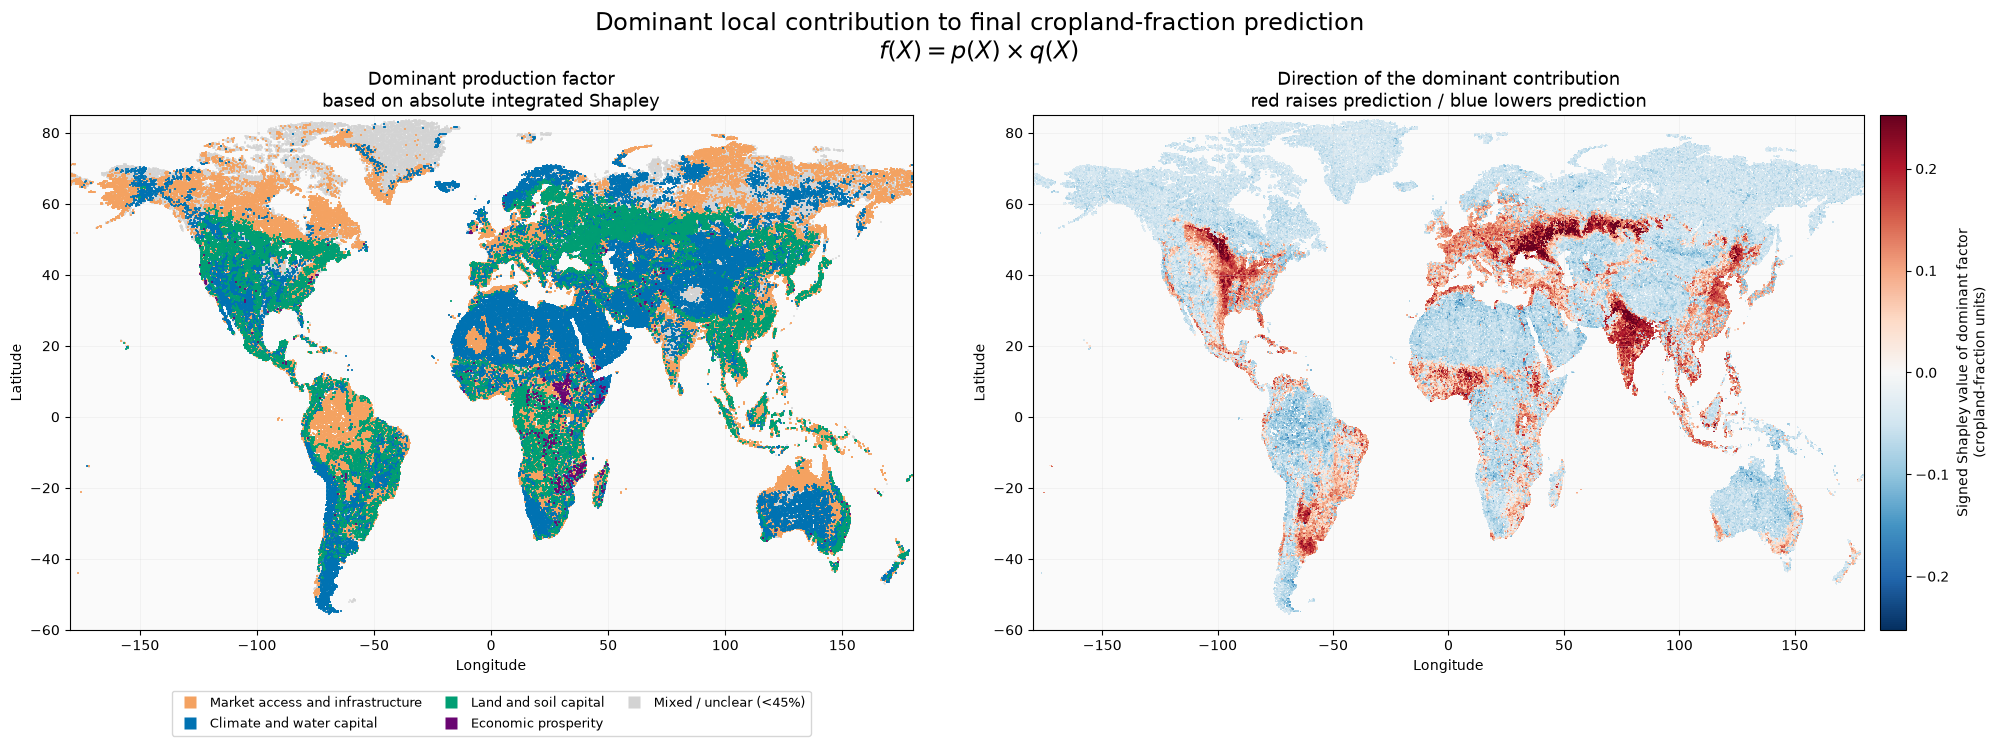

Source: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_gdp_target2020/integrated_shapley_archive_bg32_perm32/integrated_group_shapley_by_cell.csv.gz
Cells: 240,000
Color clipping limit (99th percentile): 0.25256613873410394
Saved improved figure: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_gdp_target2020/final_cropland_dominant_factor_map.png
Original-color backup: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_gdp_target2020/final_cropland_dominant_factor_map_original_colors.png
Saved summary: /work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_gdp_target2020/final_cropland_dominant_factor_summary_high_contrast.csv


,dominant_factor,n_cells,share_percent
0,Mixed / unclear,89151,37.146250
1,Market access and infrastructure,68105,28.377083
2,Climate and water capital,53403,22.251250
3,Land and soil capital,28536,11.890000
4,Economic prosperity,805,0.335417


5803

In [1]:
from pathlib import Path
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable

RESULT_DIR = Path(r"/work/tsuda/GAEZ/CroplandRegression/soil_group_calorie_only_50km_groundwater_gdp_target2020")
SOURCE_PATH = (
    RESULT_DIR
    / "integrated_shapley_archive_bg32_perm32"
    / "integrated_group_shapley_by_cell.csv.gz"
)
FIGURE_PATH = RESULT_DIR / "final_cropland_dominant_factor_map.png"
BACKUP_PATH = RESULT_DIR / "final_cropland_dominant_factor_map_original_colors.png"
SUMMARY_PATH = RESULT_DIR / "final_cropland_dominant_factor_summary_high_contrast.csv"

MIN_DOMINANCE_SHARE = 0.45
MIXED_LABEL = "Mixed / unclear"

# High-contrast palette. GDP is magenta rather than green.
GROUP_COLORS = {
    "Market access and infrastructure": "#F4A261",
    "Climate and water capital": "#0072B2",
    "Land and soil capital": "#009E73",
    "Economic prosperity": "#6A0572",
    MIXED_LABEL: "#D3D3D3",
}
GROUP_ORDER = [
    "Market access and infrastructure",
    "Climate and water capital",
    "Land and soil capital",
    "Economic prosperity",
]

if FIGURE_PATH.is_file() and not BACKUP_PATH.exists():
    shutil.copy2(FIGURE_PATH, BACKUP_PATH)

usecols = [
    "lat", "lon", "dominant_group", "dominant_group_share",
    "dominant_group_signed_shapley",
]
cells = pd.read_csv(SOURCE_PATH, usecols=usecols)
cells = cells.dropna(subset=usecols).copy()
cells["display_group"] = cells["dominant_group"]
cells.loc[
    cells["dominant_group_share"] < MIN_DOMINANCE_SHARE,
    "display_group",
] = MIXED_LABEL

summary = (
    cells["display_group"]
    .value_counts()
    .rename_axis("dominant_factor")
    .reset_index(name="n_cells")
)
summary["share_percent"] = 100.0 * summary["n_cells"] / len(cells)
summary.to_csv(SUMMARY_PATH, index=False)

fig, (ax_factor, ax_direction) = plt.subplots(
    1,
    2,
    figsize=(20, 7.8),
    gridspec_kw={"width_ratios": [1, 1.04]},
)

# Draw unclear cells first as a neutral land-context layer.
mixed = cells[cells["display_group"].eq(MIXED_LABEL)]
ax_factor.scatter(
    mixed["lon"], mixed["lat"],
    s=1.15, marker="s", c=GROUP_COLORS[MIXED_LABEL],
    alpha=0.56, linewidths=0, rasterized=True, zorder=1,
)

for group in GROUP_ORDER:
    subset = cells[cells["display_group"].eq(group)]
    ax_factor.scatter(
        subset["lon"], subset["lat"],
        s=1.50,
        marker="s",
        c=GROUP_COLORS[group],
        alpha=0.88,
        linewidths=0,
        rasterized=True,
        zorder=2,
    )

legend_handles = [
    Line2D(
        [0], [0], marker="s", linestyle="none", markersize=8,
        markerfacecolor=GROUP_COLORS[group], markeredgecolor="none",
        label=group,
    )
    for group in GROUP_ORDER
]
legend_handles.append(
    Line2D(
        [0], [0], marker="s", linestyle="none", markersize=8,
        markerfacecolor=GROUP_COLORS[MIXED_LABEL], markeredgecolor="none",
        label=f"{MIXED_LABEL} (<{MIN_DOMINANCE_SHARE:.0%})",
    )
)
ax_factor.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.105),
    ncol=3,
    frameon=True,
    fontsize=9.5,
    columnspacing=1.2,
    handletextpad=0.5,
)
ax_factor.set_title(
    "Dominant production factor\n"
    "based on absolute integrated Shapley",
    fontsize=13,
)

signed = cells["dominant_group_signed_shapley"].to_numpy(float)
color_limit = float(np.nanquantile(np.abs(signed), 0.99))
if not np.isfinite(color_limit) or color_limit <= 0:
    color_limit = 1.0
norm = TwoSlopeNorm(vmin=-color_limit, vcenter=0.0, vmax=color_limit)
cmap = plt.get_cmap("RdBu_r")

ax_direction.scatter(
    cells["lon"], cells["lat"],
    c=np.clip(signed, -color_limit, color_limit),
    cmap=cmap,
    norm=norm,
    s=1.35,
    marker="s",
    alpha=0.90,
    linewidths=0,
    rasterized=True,
)
colorbar = fig.colorbar(
    ScalarMappable(norm=norm, cmap=cmap),
    ax=ax_direction,
    fraction=0.034,
    pad=0.018,
)
colorbar.set_label(
    "Signed Shapley value of dominant factor\n"
    "(cropland-fraction units)",
    fontsize=10,
)
ax_direction.set_title(
    "Direction of the dominant contribution\n"
    "red raises prediction / blue lowers prediction",
    fontsize=13,
)

for ax in (ax_factor, ax_direction):
    ax.set_xlim(-180, 180)
    ax.set_ylim(-60, 85)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_facecolor("#FAFAFA")
    ax.grid(True, color="#D9D9D9", alpha=0.35, linewidth=0.55)

fig.suptitle(
    "Dominant local contribution to final cropland-fraction prediction\n"
    r"$f(X)=p(X)\times q(X)$",
    fontsize=17,
    y=0.975,
)
fig.subplots_adjust(left=0.045, right=0.965, bottom=0.18, top=0.84, wspace=0.14)
fig.savefig(FIGURE_PATH, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Source:", SOURCE_PATH)
print("Cells:", f"{len(cells):,}")
print("Color clipping limit (99th percentile):", color_limit)
print("Saved improved figure:", FIGURE_PATH)
print("Original-color backup:", BACKUP_PATH)
print("Saved summary:", SUMMARY_PATH)
display(summary)

result_files = sorted(
    str(path.relative_to(RESULT_DIR))
    for path in RESULT_DIR.rglob("*")
    if path.is_file()
)
(RESULT_DIR / "result_file_index.txt").write_text(
    "\n".join(result_files) + "\n",
    encoding="utf-8",
)
